# Priors for Item Parameters (mirt/ltm-style)

This notebook illustrates how **item priors** influence parameter estimates.
We mirror workflows in the R **mirt** and **ltm** packages by using the same
reference datasets found in `tests/mirt_reference/` and `tests/ltm_reference/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from irt import fit

## 1) Load LSAT7 data (mirt reference)

We use the LSAT7 dataset shipped with the `mirt` reference outputs.

In [2]:
lsat7 = pd.read_csv("../tests/mirt_reference/lsat7_data.csv")
lsat7.shape

(1000, 5)

## 2) Fit 2PL without priors

In [3]:
twopl_no = fit(lsat7, model="2pl", estimator="mml_em")
twopl_no

FitResult(model='2pl', estimator='mml_em', n_items=5, n_persons=1000, n_iter=43, converged, loglik=-2658.85)

## 3) Fit 2PL with item priors (mirt-style shrinkage)

We place a **lognormal** prior on discrimination `a` and a **normal** prior on
difficulty `b` for selected items to see the shrinkage effect.

In [4]:
target_item = lsat7.columns[0]
other_item = lsat7.columns[1]

priors_dict = {
    "a": [
        {"dist": "lognormal", "mean": 0.0, "sd": 0.4, "items": [target_item]},
    ],
    "b": [
        {"dist": "normal", "mean": 0.0, "sd": 0.5, "items": [target_item, other_item]},
    ],
}

twopl_prior = fit(lsat7, model="2pl", estimator="mml_em", priors=priors_dict)
twopl_prior

FitResult(model='2pl', estimator='mml_em', n_items=5, n_persons=1000, n_iter=54, converged, loglik=-2659.46)

In [5]:
compare_2pl = pd.DataFrame({
    "item": lsat7.columns,
    "a_no": twopl_no.params["a"],
    "a_prior": twopl_prior.params["a"],
    "b_no": twopl_no.params["b"],
    "b_prior": twopl_prior.params["b"],
})
compare_2pl["a_diff"] = compare_2pl["a_prior"] - compare_2pl["a_no"]
compare_2pl["b_diff"] = compare_2pl["b_prior"] - compare_2pl["b_no"]

compare_2pl[compare_2pl["item"].isin([target_item, other_item])]

,item,a_no,a_prior,b_no,b_prior,a_diff,b_diff
0,Item.1,0.988527,1.151310,-1.877717,-1.636129,0.162783,0.241588
1,Item.2,1.080959,1.100833,-0.747428,-0.715057,0.019874,0.032371


## 3b) Visualize shrinkage

We plot parameter shifts for the targeted items.

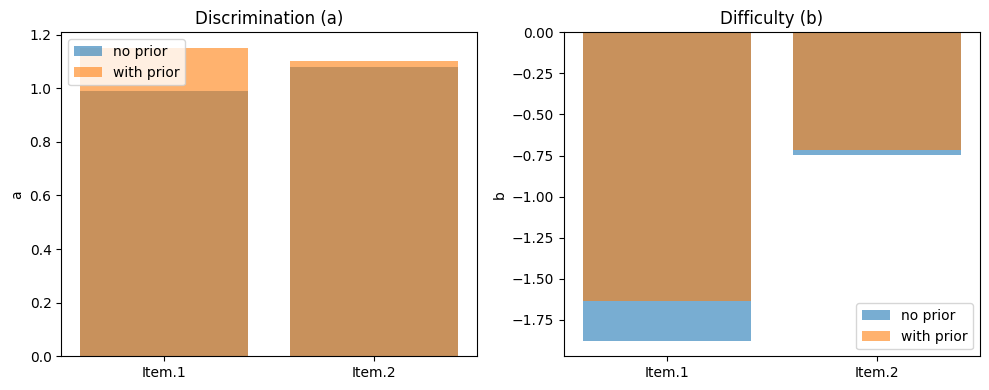

In [6]:
import matplotlib.pyplot as plt

subset = compare_2pl[compare_2pl["item"].isin([target_item, other_item])].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(subset["item"], subset["a_no"], alpha=0.6, label="no prior")
axes[0].bar(subset["item"], subset["a_prior"], alpha=0.6, label="with prior")
axes[0].set_title("Discrimination (a)")
axes[0].set_ylabel("a")
axes[0].legend()

axes[1].bar(subset["item"], subset["b_no"], alpha=0.6, label="no prior")
axes[1].bar(subset["item"], subset["b_prior"], alpha=0.6, label="with prior")
axes[1].set_title("Difficulty (b)")
axes[1].set_ylabel("b")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4) DataFrame-style priors

The same priors can be expressed using a tidy DataFrame (similar to R formulas + data frames).

In [7]:
priors_df = pd.DataFrame(
    [
        {"item": target_item, "param": "a", "dist": "lognormal", "mean": 0.0, "sd": 0.4},
        {"item": target_item, "param": "b", "dist": "normal", "mean": 0.0, "sd": 0.5},
        {"item": other_item, "param": "b", "dist": "normal", "mean": 0.0, "sd": 0.5},
    ]
)

twopl_prior_df = fit(lsat7, model="2pl", estimator="mml_em", priors=priors_df)
compare_df = pd.DataFrame({
    "item": lsat7.columns,
    "a_no": twopl_no.params["a"],
    "a_prior_df": twopl_prior_df.params["a"],
    "b_no": twopl_no.params["b"],
    "b_prior_df": twopl_prior_df.params["b"],
})
compare_df[compare_df["item"].isin([target_item, other_item])]


,item,a_no,a_prior_df,b_no,b_prior_df
0,Item.1,0.988527,1.151310,-1.877717,-1.636129
1,Item.2,1.080959,1.100833,-0.747428,-0.715057


## 5) Rasch example (ltm-style)

We use the LSAT data from the `ltm` reference outputs and apply normal priors
to a couple of difficulties to show shrinkage.

In [8]:
lsat_ltm = pd.read_csv("../tests/ltm_reference/lsat_data.csv")

rasch_no = fit(lsat_ltm, model="rasch", estimator="mml_em")

ltm_item_a = lsat_ltm.columns[0]
ltm_item_b = lsat_ltm.columns[1]

priors_rasch = pd.DataFrame(
    [
        {"item": ltm_item_a, "param": "b", "dist": "normal", "mean": 0.0, "sd": 0.4},
        {"item": ltm_item_b, "param": "b", "dist": "normal", "mean": 0.0, "sd": 0.4},
    ]
)

rasch_prior = fit(lsat_ltm, model="rasch", estimator="mml_em", priors=priors_rasch)

compare_rasch = pd.DataFrame({
    "item": lsat_ltm.columns,
    "b_no": rasch_no.params["b"],
    "b_prior": rasch_prior.params["b"],
})
compare_rasch[compare_rasch["item"].isin([ltm_item_a, ltm_item_b])]


,item,b_no,b_prior
0,Item 1,-2.871805,-2.615002
1,Item 2,-1.062971,-1.003240


## What to observe

- Items with priors move toward the prior mean/shape compared to the no-prior fit.
- Lognormal/gamma priors on `a` keep discriminations positive and can reduce extreme values.
- Normal priors on `b` reduce extreme difficulties for sparse items.